In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt

print("TF:", tf.__version__)
print("GPU:", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

# ==============================
# Paths
# ==============================
DATA_DIR = "database"
EVAL_FILE = "small_cases.csv"   # <- 평가용 CSV로 교체

QUALITY_MODEL_PATH = "best_model_residue.h5"       # frozen quality ANN
POLICY_MODEL_PATH  = "best_policy_net.keras"      # trained policy ANN (input 39)

SCALER_X_PATH = "scaler_x_38.pkl"                 # for [u, mon, qprev] (38)
SCALER_Y_PATH = "scaler_y_1.pkl"                  # for residue scaling (1)

# 학습 때와 동일하게
DELTA_MAX_DEFAULT = 0.02

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


TF: 2.10.0
GPU: available


In [2]:
# ============================================================
# Column definitions (TRAIN과 동일해야 함)
# ============================================================

CONTROL_COLS_9 = [
    "RP_roller_p1",
    "RP_roller_p2",
    "RP_sep_rpm",
    "RP_sep_fan_damper",
    "RP_sep_BF_damper",
    "mill_BF_damper",
    "mill_sep_rpm",
    "mill_sep_fan_damper",
    "grind_aid",
]
assert len(CONTROL_COLS_9) == 9

MONITOR_COLS_28 = [
    "RP_spac",
    "RP_skew",
    "RP_roller_energy1",
    "RP_roller_energy2",
    "RP_roller_vib",
    "RP_BE_energy1",
    "RP_BE_energy2",
    "RP_sep_BF_pressure",
    "dosing_BE_energy",
    "mill_feed_c",
    "mill_feed_cir",
    "mill_energy",
    "mill_in_temp",
    "mill_out_temp",
    "mill_BE_energy",
    "mill_out_gas_temp",
    "mill_out_mater_temp",
    "mill_BF_pressure",
    "mill_sep_BF_pressure",
    "mill_sep_BF_fan_damper",
    "final_BE_1",
    "final_BE_2",
    "final_mater_temp",
    "feed_clinker",
    "feed_gypsum",
    "feed_slag",
    "feed_FA",
    "feed_total",
]
assert len(MONITOR_COLS_28) == 28

QUALITY_PREV_COL   = "residue_prev"
POLICY_CUR_COL     = "residue"
TARGET_QUALITY_COL = "residue_target"

QUALITY_INPUT_COLS = CONTROL_COLS_9 + MONITOR_COLS_28 + [QUALITY_PREV_COL]
assert len(QUALITY_INPUT_COLS) == 38

# policy_net 입력은 39
POLICY_INPUT_DIM = 28 + 1 + 9 + 1
assert POLICY_INPUT_DIM == 39

print("QUALITY_INPUT_DIM:", len(QUALITY_INPUT_COLS))
print("POLICY_INPUT_DIM :", POLICY_INPUT_DIM)


QUALITY_INPUT_DIM: 38
POLICY_INPUT_DIM : 39


In [3]:
csv_path = os.path.join(DATA_DIR, EVAL_FILE)
df = pd.read_csv(csv_path)

required_cols = list(set(QUALITY_INPUT_COLS + [POLICY_CUR_COL, TARGET_QUALITY_COL]))
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in EVAL CSV: {missing_cols}")

df = df.dropna(subset=required_cols).reset_index(drop=True)
print("Loaded eval data:", df.shape, "from", csv_path)

display(df.head())

scaler_x = joblib.load(SCALER_X_PATH)
scaler_y = joblib.load(SCALER_Y_PATH)

quality_model = tf.keras.models.load_model(QUALITY_MODEL_PATH)
quality_model.trainable = False

policy_net = tf.keras.models.load_model(POLICY_MODEL_PATH)
policy_net.trainable = False

print("Loaded:")
print("- scaler_x:", SCALER_X_PATH)
print("- scaler_y:", SCALER_Y_PATH)
print("- quality_model:", QUALITY_MODEL_PATH, "in/out:", quality_model.input_shape, quality_model.output_shape)
print("- policy_net:", POLICY_MODEL_PATH, "out:", policy_net.output_shape)

def build_eval_tensors(df_raw: pd.DataFrame, scaler_x, scaler_y):
    """
    학습 CELL7 로직을 eval에서 그대로 재현:
      Xq_raw  = [u_cur, mon, qprev]  -> scaler_x -> u_cur_norm, mon_norm, qprev_norm
      qcur_norm, yT_norm -> scaler_y
      Xp_full = [mon_norm, qcur_norm, u_cur_norm, yT_norm, qprev_norm]  (N,40)
      Xp_no_prev = Xp_full[:, :39]  (N,39)  -> policy_net input
    """
    u_cur_raw = df_raw[CONTROL_COLS_9].to_numpy(np.float32)          # (N,9)
    mon_raw   = df_raw[MONITOR_COLS_28].to_numpy(np.float32)         # (N,28)
    qprev_raw = df_raw[[QUALITY_PREV_COL]].to_numpy(np.float32)      # (N,1)
    qcur_raw  = df_raw[[POLICY_CUR_COL]].to_numpy(np.float32)        # (N,1)
    yT_raw    = df_raw[[TARGET_QUALITY_COL]].to_numpy(np.float32)    # (N,1)

    # quality raw/norm
    Xq_raw  = np.concatenate([u_cur_raw, mon_raw, qprev_raw], axis=1)         # (N,38)
    Xq_norm = scaler_x.transform(Xq_raw).astype(np.float32)                   # (N,38)

    u_cur_norm = Xq_norm[:, :9]                                              # (N,9)
    mon_norm   = Xq_norm[:, 9:9+28]                                          # (N,28)
    qprev_norm = Xq_norm[:, 9+28:9+28+1]                                     # (N,1)

    # policy scalers
    qcur_norm = scaler_y.transform(qcur_raw).astype(np.float32)              # (N,1)
    yT_norm   = scaler_y.transform(yT_raw).astype(np.float32)                # (N,1)

    # Xp_full (N,40)
    Xp_full = np.concatenate([mon_norm, qcur_norm, u_cur_norm, yT_norm, qprev_norm], axis=1).astype(np.float32)
    assert Xp_full.shape[1] == POLICY_INPUT_DIM + 1   # 40

    # policy input only (N,39)
    Xp_no_prev = Xp_full[:, :39]
    assert Xp_no_prev.shape[1] == POLICY_INPUT_DIM

    return {
        "Xp_full": Xp_full,
        "Xp_no_prev": Xp_no_prev,
        "u_cur_raw": u_cur_raw,
        "qcur_raw": qcur_raw,
        "qprev_raw": qprev_raw,
        "yT_raw": yT_raw,
        "u_cur_norm": u_cur_norm,
        "mon_norm": mon_norm,
        "qprev_norm": qprev_norm,
        "qcur_norm": qcur_norm,
        "yT_norm": yT_norm,
    }


Loaded eval data: (9, 43) from database\small_cases.csv


,RP_roller_p1,RP_roller_p2,RP_sep_rpm,RP_sep_fan_damper,RP_sep_BF_damper,mill_BF_damper,mill_sep_rpm,mill_sep_fan_damper,grind_aid,RP_spac,RP_skew,RP_roller_energy1,RP_roller_energy2,RP_roller_vib,RP_BE_energy1,RP_BE_energy2,RP_sep_BF_pressure,dosing_BE_energy,mill_feed_c,mill_feed_cir,mill_energy,mill_in_temp,mill_out_temp,mill_BE_energy,mill_out_gas_temp,mill_out_mater_temp,mill_BF_pressure,mill_sep_BF_pressure,mill_sep_BF_fan_damper,final_BE_1,final_BE_2,final_mater_temp,feed_total,feed_clinker,feed_gypsum,feed_slag,feed_FA,blaine,residue,blaine_prev,residue_prev,blaine_target,residue_target
0,74,73,463,100,60,25,1112,100,149.4,46,1,147,144,1.0,0,124,-103,22,364,576,163,50,58,68,109,115,-149,-283,30,88,77,95,223.2,189.6,11.3,11.1,11.2,3550,8.9,3720,8.7,3800,8
1,73,77,390,100,60,15,1165,100,151.2,43,0,145,133,1.5,0,124,-84,20,338,546,172,34,43,71,95,101,-132,-236,30,90,78,78,221.1,190.1,11.2,11.0,8.8,3700,7.8,3860,8.5,3800,8
2,68,77,445,100,60,15,1156,100,151.2,49,0,148,141,1.3,0,125,-68,19,389,613,161,46,54,71,99,105,-115,-224,30,90,78,88,217.2,186.7,11.0,10.8,8.7,3780,8.2,3590,8.5,3800,8
3,78,79,462,100,60,15,1146,100,158.4,48,0,159,151,1.1,0,121,-72,20,398,613,168,45,53,74,101,108,-121,-219,30,72,61,89,220.2,186.3,10.7,11.0,12.2,3570,8.6,3680,8.3,3800,8
4,74,76,446,100,60,20,1139,100,199.8,42,7,153,146,1.2,0,124,-86,20,360,571,168,49,56,70,110,116,-128,-268,30,85,77,95,217.9,184.8,11.3,10.9,10.9,3610,8.7,3590,8.6,3800,8


Loaded:
- scaler_x: scaler_x_38.pkl
- scaler_y: scaler_y_1.pkl
- quality_model: best_model_residue.h5 in/out: (None, 38) (None, 1)
- policy_net: best_policy_net.keras out: (None, 9)


In [4]:
def eval_policy(df_raw: pd.DataFrame,
                policy_net,
                quality_model,
                scaler_x,
                scaler_y,
                delta_max_default: float = 0.02) -> pd.DataFrame:
    pack = build_eval_tensors(df_raw, scaler_x, scaler_y)

    Xp_no_prev = pack["Xp_no_prev"]             # (N,39) policy input
    mon_norm   = pack["mon_norm"]               # (N,28)
    u_cur_norm = pack["u_cur_norm"]             # (N,9)
    qprev_norm = pack["qprev_norm"]             # (N,1)

    u_cur_raw  = pack["u_cur_raw"]              # (N,9) raw unit
    qcur_raw   = pack["qcur_raw"].reshape(-1)   # (N,)
    qprev_raw  = pack["qprev_raw"].reshape(-1)  # (N,)
    yT_raw     = pack["yT_raw"].reshape(-1)     # (N,)

    # 1) policy forward (delta_raw in [-1,1])
    delta_raw = policy_net(Xp_no_prev, training=False).numpy().astype(np.float32)   # (N,9)
    DELTA_MAX = np.array([delta_max_default]*9, dtype=np.float32).reshape(1, -1)
    delta_norm = delta_raw * DELTA_MAX                                              # (N,9)

    u_new_norm = np.clip(u_cur_norm + delta_norm, 0.0, 1.0)                         # (N,9)

    # 2) quality forward (38): [u_new, mon, qprev]
    Xq_new_norm = np.concatenate([u_new_norm, mon_norm, qprev_norm], axis=1).astype(np.float32)  # (N,38)
    y_pred_norm = quality_model(Xq_new_norm, training=False).numpy().astype(np.float32)          # (N,1)

    # 3) inverse to real unit (residue)
    y_pred_real = scaler_y.inverse_transform(y_pred_norm).reshape(-1)               # (N,)

    # 4) inverse to raw unit for u_new (controls)
    Xq_new_raw = scaler_x.inverse_transform(Xq_new_norm).astype(np.float32)         # (N,38)
    u_new_raw = Xq_new_raw[:, :9]                                                   # (N,9)
    delta_raw_unit = u_new_raw - u_cur_raw                                          # (N,9)

    # 5) result table
    out = pd.DataFrame({
        "qcur(residue)": qcur_raw,
        "qprev(residue_prev)": qprev_raw,
        "target(residue_target)": yT_raw,
        "pred(residue_pred)": y_pred_real,
        "target-pred": (yT_raw - y_pred_real),
        "pred-qcur": (y_pred_real - qcur_raw),
    })

    for i, c in enumerate(CONTROL_COLS_9):
        out[f"{c}_cur"]   = u_cur_raw[:, i]
        out[f"{c}_new"]   = u_new_raw[:, i]
        out[f"{c}_delta"] = delta_raw_unit[:, i]

    return out


In [5]:
result_df = eval_policy(
    df_raw=df,
    policy_net=policy_net,
    quality_model=quality_model,
    scaler_x=scaler_x,
    scaler_y=scaler_y,
    delta_max_default=DELTA_MAX_DEFAULT
)

display(result_df)


,qcur(residue),qprev(residue_prev),target(residue_target),pred(residue_pred),target-pred,pred-qcur,RP_roller_p1_cur,RP_roller_p1_new,RP_roller_p1_delta,RP_roller_p2_cur,RP_roller_p2_new,RP_roller_p2_delta,RP_sep_rpm_cur,RP_sep_rpm_new,RP_sep_rpm_delta,RP_sep_fan_damper_cur,RP_sep_fan_damper_new,RP_sep_fan_damper_delta,RP_sep_BF_damper_cur,RP_sep_BF_damper_new,RP_sep_BF_damper_delta,mill_BF_damper_cur,mill_BF_damper_new,mill_BF_damper_delta,mill_sep_rpm_cur,mill_sep_rpm_new,mill_sep_rpm_delta,mill_sep_fan_damper_cur,mill_sep_fan_damper_new,mill_sep_fan_damper_delta,grind_aid_cur,grind_aid_new,grind_aid_delta
0,8.9,8.7,8.0,8.514277,-0.514277,-0.385723,74.0,73.992584,-0.007416,73.0,72.985542,-0.014458,463.0,462.999542,-0.000458,100.0,100.0,0.0,60.0,59.999146,-0.000854,25.0,25.000475,0.000475,1112.0,1111.917358,-0.082642,100.0,100.000000,0.000000,149.399994,149.406311,0.006317
1,7.8,8.5,8.0,8.242155,-0.242155,0.442155,73.0,73.001938,0.001938,77.0,76.990814,-0.009186,390.0,389.992676,-0.007324,100.0,100.0,0.0,60.0,60.000595,0.000595,15.0,15.000857,0.000857,1165.0,1164.859741,-0.140259,100.0,100.000000,0.000000,151.199997,151.162125,-0.037872
2,8.2,8.5,8.0,8.285707,-0.285707,0.085707,68.0,67.987167,-0.012833,77.0,76.985901,-0.014099,445.0,445.001678,0.001678,100.0,100.0,0.0,60.0,59.998775,-0.001225,15.0,15.000669,0.000669,1156.0,1155.967896,-0.032104,100.0,100.000000,0.000000,151.199997,151.127655,-0.072342
3,8.6,8.3,8.0,8.092421,-0.092421,-0.507580,78.0,77.990425,-0.009575,79.0,78.986481,-0.013519,462.0,462.002258,0.002258,100.0,100.0,0.0,60.0,59.998196,-0.001804,15.0,15.000334,0.000334,1146.0,1146.068237,0.068237,100.0,100.000000,0.000000,158.399994,158.366959,-0.033035
4,8.7,8.6,8.0,8.356509,-0.356509,-0.343491,74.0,73.976753,-0.023247,76.0,75.981888,-0.018112,446.0,446.002136,0.002136,100.0,100.0,0.0,60.0,59.999149,-0.000851,20.0,20.000854,0.000854,1139.0,1138.914307,-0.085693,100.0,100.000000,0.000000,199.800003,199.821030,0.021027
5,8.5,8.4,8.0,8.200980,-0.200980,-0.299020,78.0,77.999130,-0.000870,77.0,76.988281,-0.011719,454.0,454.004364,0.004364,100.0,100.0,0.0,60.0,59.998390,-0.001610,20.0,20.000055,0.000055,1145.0,1145.098145,0.098145,100.0,100.000000,0.000000,210.600006,210.568436,-0.031570
6,8.7,9.0,8.0,8.409611,-0.409611,-0.290389,81.0,80.992165,-0.007835,83.0,82.985367,-0.014633,404.0,403.999176,-0.000824,100.0,100.0,0.0,60.0,59.999546,-0.000454,20.0,20.000015,0.000015,1119.0,1118.974731,-0.025269,100.0,100.000000,0.000000,210.600006,210.574203,-0.025803
7,9.0,8.1,8.0,8.026378,-0.026378,-0.973622,81.0,80.988976,-0.011024,83.0,82.988548,-0.011452,472.0,472.001862,0.001862,100.0,100.0,0.0,60.0,59.999332,-0.000668,25.0,25.000319,0.000319,1102.0,1101.961426,-0.038574,100.0,100.000000,0.000000,149.399994,149.396561,-0.003433
8,4.5,4.7,8.0,6.925228,1.074772,2.425228,76.0,79.819756,3.819756,85.0,81.410759,-3.589241,467.0,466.896667,-0.103333,100.0,100.0,0.0,40.0,40.013180,0.013180,30.0,29.997675,-0.002325,1037.0,1012.521912,-24.478088,100.0,99.998932,-0.001068,156.100006,170.712067,14.612061


In [6]:
summary_cols = [
    "qcur(residue)", "qprev(residue_prev)", "target(residue_target)",
    "pred(residue_pred)", "target-pred", "pred-qcur"
]
delta_cols = [f"{c}_delta" for c in CONTROL_COLS_9]

print("===== Summary =====")
display(result_df[summary_cols])

print("===== Control deltas (raw unit) =====")
display(result_df[delta_cols])


===== Summary =====


,qcur(residue),qprev(residue_prev),target(residue_target),pred(residue_pred),target-pred,pred-qcur
0,8.9,8.7,8.0,8.514277,-0.514277,-0.385723
1,7.8,8.5,8.0,8.242155,-0.242155,0.442155
2,8.2,8.5,8.0,8.285707,-0.285707,0.085707
3,8.6,8.3,8.0,8.092421,-0.092421,-0.507580
4,8.7,8.6,8.0,8.356509,-0.356509,-0.343491
5,8.5,8.4,8.0,8.200980,-0.200980,-0.299020
6,8.7,9.0,8.0,8.409611,-0.409611,-0.290389
7,9.0,8.1,8.0,8.026378,-0.026378,-0.973622
8,4.5,4.7,8.0,6.925228,1.074772,2.425228


===== Control deltas (raw unit) =====


,RP_roller_p1_delta,RP_roller_p2_delta,RP_sep_rpm_delta,RP_sep_fan_damper_delta,RP_sep_BF_damper_delta,mill_BF_damper_delta,mill_sep_rpm_delta,mill_sep_fan_damper_delta,grind_aid_delta
0,-0.007416,-0.014458,-0.000458,0.0,-0.000854,0.000475,-0.082642,0.000000,0.006317
1,0.001938,-0.009186,-0.007324,0.0,0.000595,0.000857,-0.140259,0.000000,-0.037872
2,-0.012833,-0.014099,0.001678,0.0,-0.001225,0.000669,-0.032104,0.000000,-0.072342
3,-0.009575,-0.013519,0.002258,0.0,-0.001804,0.000334,0.068237,0.000000,-0.033035
4,-0.023247,-0.018112,0.002136,0.0,-0.000851,0.000854,-0.085693,0.000000,0.021027
5,-0.000870,-0.011719,0.004364,0.0,-0.001610,0.000055,0.098145,0.000000,-0.031570
6,-0.007835,-0.014633,-0.000824,0.0,-0.000454,0.000015,-0.025269,0.000000,-0.025803
7,-0.011024,-0.011452,0.001862,0.0,-0.000668,0.000319,-0.038574,0.000000,-0.003433
8,3.819756,-3.589241,-0.103333,0.0,0.013180,-0.002325,-24.478088,-0.001068,14.612061


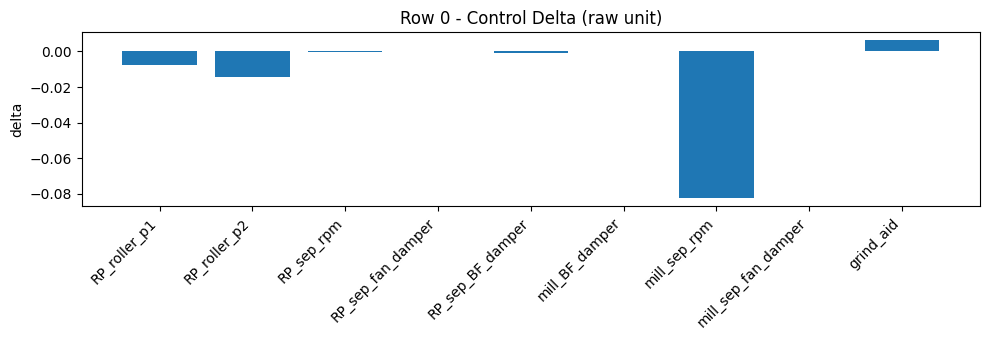

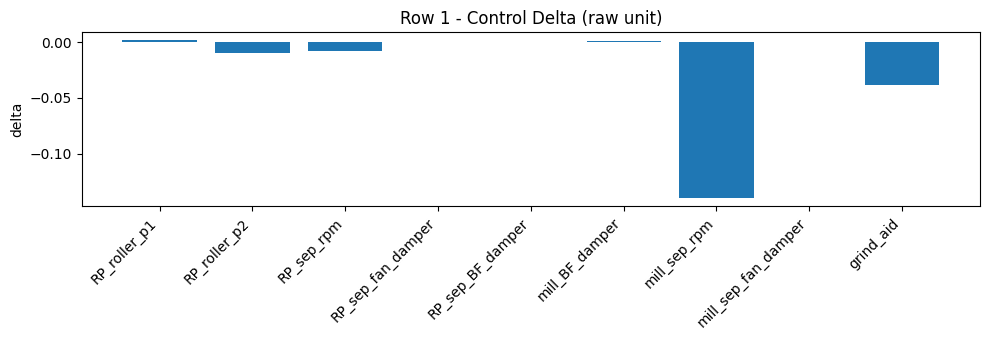

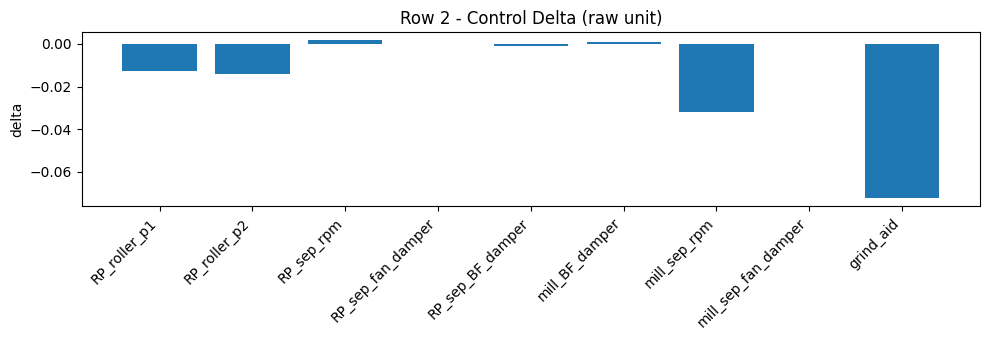

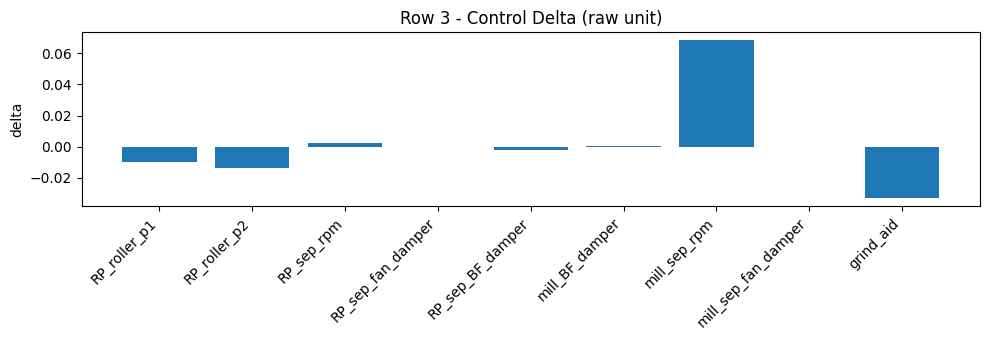

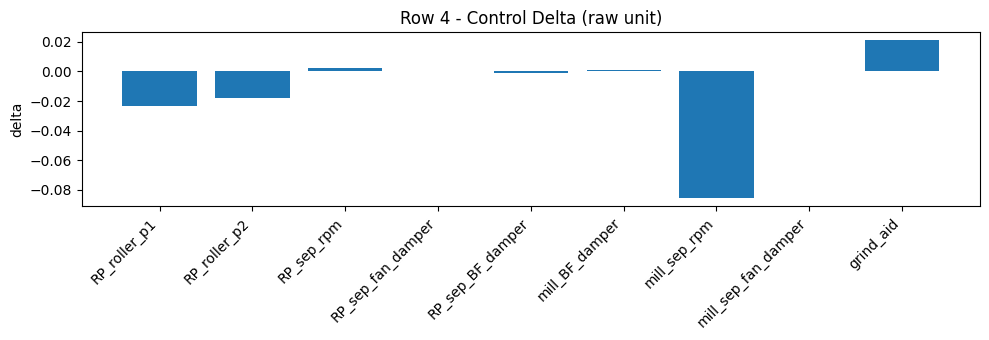

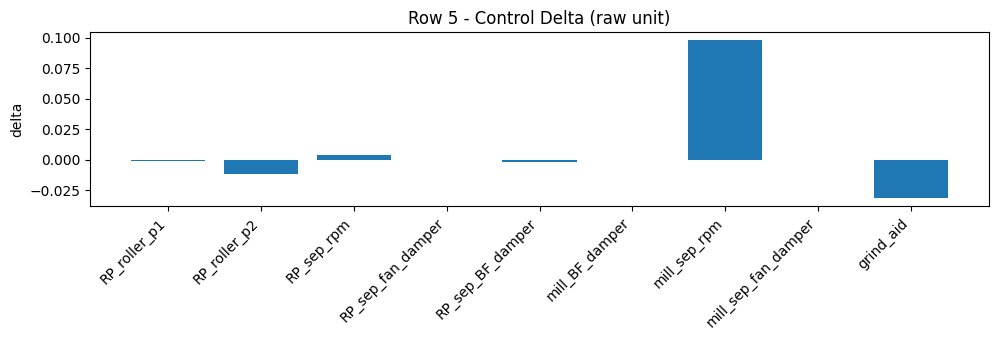

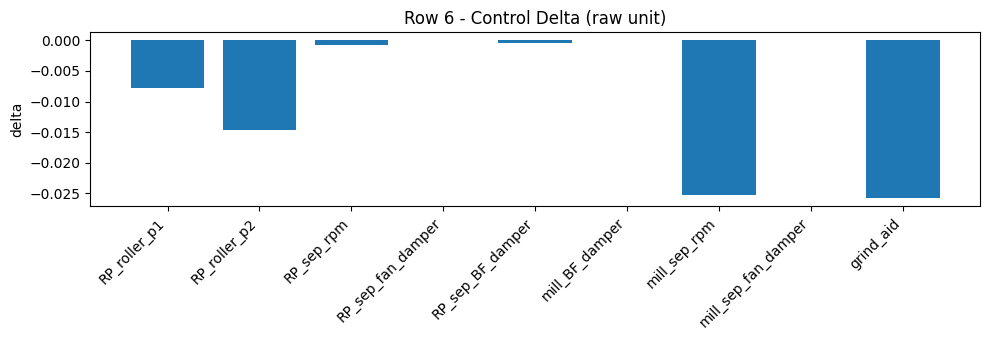

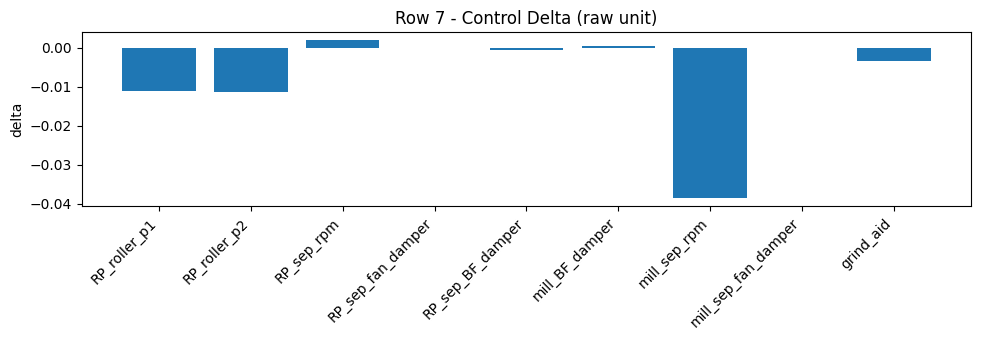

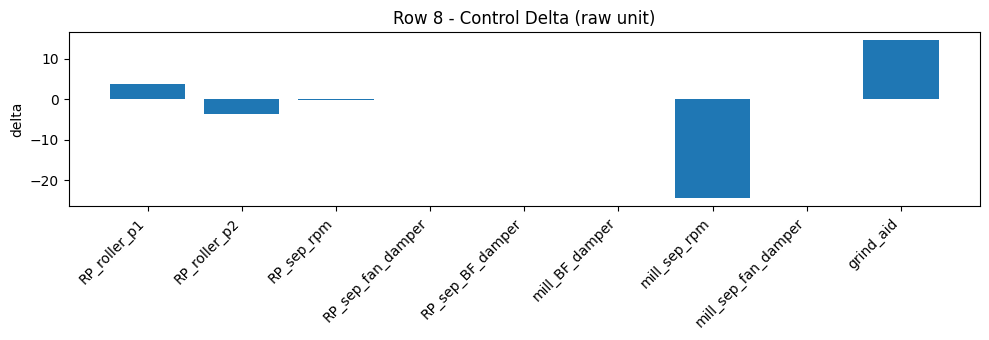

In [7]:
for row_idx in range(len(result_df)):
    deltas = result_df.loc[row_idx, [f"{c}_delta" for c in CONTROL_COLS_9]].to_numpy(np.float32)

    plt.figure(figsize=(10, 3.5))
    plt.bar(np.arange(len(CONTROL_COLS_9)), deltas)
    plt.xticks(np.arange(len(CONTROL_COLS_9)), CONTROL_COLS_9, rotation=45, ha="right")
    plt.title(f"Row {row_idx} - Control Delta (raw unit)")
    plt.ylabel("delta")
    plt.tight_layout()
    plt.show()


In [8]:
OUT_PATH = "eval_policy_result.csv"
result_df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print("Saved:", OUT_PATH)


Saved: eval_policy_result.csv


In [9]:
def make_policy_input_39(u_cur_raw, mon_raw, qcur_raw, yT_raw, scaler_x, scaler_y):
    """
    policy input = [mon_norm(28), qcur_norm(1), u_cur_norm(9), yT_norm(1)]  => (1,39)
    주의: u_cur_norm/mon_norm은 scaler_x로 만든 Xq_norm에서 가져오므로
         qprev_raw도 같이 넣어 Xq_raw(38)을 구성한 뒤 분해합니다.
    """
    # 임시로 qprev를 넣어서 scaler_x 변환 공간을 맞춤(학습 때와 동일한 scaler_x)
    # 여기서 qprev는 policy 입력에는 안 들어가지만, u_cur_norm/mon_norm 만들려면 scaler_x가 필요
    # 따라서 외부에서 qprev_raw를 별도로 넣는 버전이 더 깔끔하지만, 편의를 위해 인자로 받지 않고 0을 둘 수는 없습니다.
    raise NotImplementedError


def quality_predict_from_norm(u_new_norm, mon_norm, qprev_norm, quality_model):
    Xq_new_norm = np.concatenate([u_new_norm, mon_norm, qprev_norm], axis=1).astype(np.float32)  # (1,38)
    y_pred_norm = quality_model(Xq_new_norm, training=False).numpy().astype(np.float32)          # (1,1)
    return y_pred_norm


In [10]:
# ============================================================
# 6) 폐루프 시뮬레이션 함수
# ============================================================

def build_norm_components_from_raw(u_cur_raw, mon_raw, qprev_raw, scaler_x):
    """
    scaler_x는 [u, mon, qprev] 38차원으로 fit되어 있으므로,
    u_cur_norm, mon_norm, qprev_norm을 얻기 위해 동일하게 구성해 변환합니다.
    """
    Xq_raw = np.concatenate([u_cur_raw, mon_raw, qprev_raw], axis=1).astype(np.float32)  # (1,38)
    Xq_norm = scaler_x.transform(Xq_raw).astype(np.float32)                                # (1,38)

    u_cur_norm = Xq_norm[:, :9]
    mon_norm   = Xq_norm[:, 9:9+28]
    qprev_norm = Xq_norm[:, 9+28:9+28+1]
    return u_cur_norm, mon_norm, qprev_norm


def simulate_closed_loop(case_row: pd.Series,
                         policy_net, quality_model,
                         scaler_x, scaler_y,
                         n_steps: int = 30,
                         delta_max_default: float = 0.02):
    """
    상태(state):
      u_cur_raw  : (1,9)   현재 제어 (raw unit)
      mon_raw    : (1,28)  모니터 (raw unit)  -- 시뮬레이션에서는 고정(가정)
      qcur_raw   : (1,1)   현재 품질 (raw unit)
      qprev_raw  : (1,1)   이전 품질 (raw unit)
      yT_raw     : (1,1)   목표 품질 (raw unit) -- 고정(가정)

    loop:
      1) norm components: u_cur_norm, mon_norm, qprev_norm
      2) policy input 39: [mon_norm, qcur_norm, u_cur_norm, yT_norm]
      3) policy -> delta_norm -> u_new_norm -> clip
      4) quality input 38: [u_new_norm, mon_norm, qprev_norm] -> y_next_norm
      5) y_next_raw = inverse(scaler_y)
      6) update: qprev <- qcur, qcur <- y_next, u_cur <- u_new(raw)
    """
    # ----- initial raw
    u_cur_raw = case_row[CONTROL_COLS_9].to_numpy(np.float32).reshape(1, -1)          # (1,9)
    mon_raw   = case_row[MONITOR_COLS_28].to_numpy(np.float32).reshape(1, -1)         # (1,28)
    qprev_raw = np.array([[case_row[QUALITY_PREV_COL]]], dtype=np.float32)            # (1,1)
    qcur_raw  = np.array([[case_row[POLICY_CUR_COL]]], dtype=np.float32)              # (1,1)
    yT_raw    = np.array([[case_row[TARGET_QUALITY_COL]]], dtype=np.float32)          # (1,1)

    # delta bound
    DELTA_MAX = np.array([delta_max_default]*9, dtype=np.float32).reshape(1, -1)

    logs = []

    for k in range(n_steps):
        # (A) build norm components for current state
        u_cur_norm, mon_norm, qprev_norm = build_norm_components_from_raw(u_cur_raw, mon_raw, qprev_raw, scaler_x)

        # (B) policy input 39
        qcur_norm = scaler_y.transform(qcur_raw).astype(np.float32)   # (1,1)
        yT_norm   = scaler_y.transform(yT_raw).astype(np.float32)     # (1,1)

        Xp_39 = np.concatenate([mon_norm, qcur_norm, u_cur_norm, yT_norm], axis=1).astype(np.float32)
        assert Xp_39.shape[1] == 39

        # (C) policy forward
        delta_raw = policy_net(Xp_39, training=False).numpy().astype(np.float32)     # (1,9) in [-1,1]
        delta_norm = delta_raw * DELTA_MAX                                           # (1,9)
        u_new_norm = np.clip(u_cur_norm + delta_norm, 0.0, 1.0)                      # (1,9)

        # (D) quality forward (uses qprev_norm)
        Xq_new_norm = np.concatenate([u_new_norm, mon_norm, qprev_norm], axis=1).astype(np.float32)  # (1,38)
        y_next_norm = quality_model(Xq_new_norm, training=False).numpy().astype(np.float32)          # (1,1)

        # (E) convert to raw
        y_next_raw = scaler_y.inverse_transform(y_next_norm).astype(np.float32)      # (1,1)

        # u_new_raw 복원 (controls only)
        Xq_new_raw = scaler_x.inverse_transform(Xq_new_norm).astype(np.float32)      # (1,38)
        u_new_raw  = Xq_new_raw[:, :9]                                               # (1,9)

        # log
        logs.append({
            "step": k,
            "qprev": float(qprev_raw[0,0]),
            "qcur":  float(qcur_raw[0,0]),
            "target": float(yT_raw[0,0]),
            "pred_next": float(y_next_raw[0,0]),
            "err(target-pred_next)": float(yT_raw[0,0] - y_next_raw[0,0]),
            **{f"{c}_cur": float(u_cur_raw[0,i]) for i,c in enumerate(CONTROL_COLS_9)},
            **{f"{c}_new": float(u_new_raw[0,i]) for i,c in enumerate(CONTROL_COLS_9)},
            **{f"{c}_delta": float(u_new_raw[0,i] - u_cur_raw[0,i]) for i,c in enumerate(CONTROL_COLS_9)},
        })

        # (F) update state
        qprev_raw = qcur_raw.copy()
        qcur_raw  = y_next_raw.copy()
        u_cur_raw = u_new_raw.copy()

    return pd.DataFrame(logs)


In [20]:
# ============================================================
# 7) 시뮬레이션 작동
# ============================================================

ROW_IDX = 3   # 사용자가 1번째 row를 선택 -> 0 (0-based)
N_STEPS = 30
case_row = df.iloc[ROW_IDX]

sim_df = simulate_closed_loop(
    case_row=case_row,
    policy_net=policy_net,
    quality_model=quality_model,
    scaler_x=scaler_x,
    scaler_y=scaler_y,
    n_steps=N_STEPS,
    delta_max_default=DELTA_MAX_DEFAULT
)

display(sim_df)

,step,qprev,qcur,target,pred_next,err(target-pred_next),RP_roller_p1_cur,RP_roller_p2_cur,RP_sep_rpm_cur,RP_sep_fan_damper_cur,RP_sep_BF_damper_cur,mill_BF_damper_cur,mill_sep_rpm_cur,mill_sep_fan_damper_cur,grind_aid_cur,RP_roller_p1_new,RP_roller_p2_new,RP_sep_rpm_new,RP_sep_fan_damper_new,RP_sep_BF_damper_new,mill_BF_damper_new,mill_sep_rpm_new,mill_sep_fan_damper_new,grind_aid_new,RP_roller_p1_delta,RP_roller_p2_delta,RP_sep_rpm_delta,RP_sep_fan_damper_delta,RP_sep_BF_damper_delta,mill_BF_damper_delta,mill_sep_rpm_delta,mill_sep_fan_damper_delta,grind_aid_delta
0,0,8.300000,8.600000,8.0,8.092421,-0.092421,78.000000,79.000000,462.000000,100.0,60.000000,15.000000,1146.000000,100.0,158.399994,77.990425,78.986481,462.002258,100.0,59.998196,15.000334,1146.068237,100.0,158.366959,-0.009575,-0.013519,0.002258,0.0,-0.001804,0.000334,0.068237,0.0,-0.033035
1,1,8.600000,8.092421,8.0,8.108212,-0.108212,77.990425,78.986481,462.002258,100.0,59.998196,15.000334,1146.068237,100.0,158.366959,78.004105,78.969185,462.002563,100.0,59.997635,14.999517,1146.043823,100.0,158.431763,0.013680,-0.017296,0.000305,0.0,-0.000561,-0.000816,-0.024414,0.0,0.064804
2,2,8.092421,8.108212,8.0,8.086537,-0.086537,78.004105,78.969185,462.002563,100.0,59.997635,14.999517,1146.043823,100.0,158.431763,78.016869,78.952187,462.002655,100.0,59.997025,14.998775,1146.026245,100.0,158.494507,0.012764,-0.016998,0.000092,0.0,-0.000610,-0.000742,-0.017578,0.0,0.062744
3,3,8.108212,8.086537,8.0,8.086829,-0.086829,78.016869,78.952187,462.002655,100.0,59.997025,14.998775,1146.026245,100.0,158.494507,78.031021,78.934891,462.002502,100.0,59.996475,14.997868,1145.996582,100.0,158.564987,0.014153,-0.017296,-0.000153,0.0,-0.000549,-0.000908,-0.029663,0.0,0.070480
4,4,8.086537,8.086829,8.0,8.086855,-0.086855,78.031021,78.934891,462.002502,100.0,59.996475,14.997868,1145.996582,100.0,158.564987,78.045166,78.917885,462.002258,100.0,59.995934,14.996994,1145.968750,100.0,158.636459,0.014145,-0.017006,-0.000244,0.0,-0.000542,-0.000874,-0.027832,0.0,0.071472
5,5,8.086829,8.086855,8.0,8.086882,-0.086882,78.045166,78.917885,462.002258,100.0,59.995934,14.996994,1145.968750,100.0,158.636459,78.059639,78.900673,462.002319,100.0,59.995388,14.996116,1145.939087,100.0,158.709259,0.014473,-0.017212,0.000061,0.0,-0.000546,-0.000878,-0.029663,0.0,0.072800
6,6,8.086855,8.086882,8.0,8.086904,-0.086904,78.059639,78.900673,462.002319,100.0,59.995388,14.996116,1145.939087,100.0,158.709259,78.074493,78.883652,462.002930,100.0,59.994923,14.995199,1145.909058,100.0,158.783615,0.014854,-0.017021,0.000610,0.0,-0.000465,-0.000916,-0.030029,0.0,0.074356
7,7,8.086882,8.086904,8.0,8.086996,-0.086996,78.074493,78.883652,462.002930,100.0,59.994923,14.995199,1145.909058,100.0,158.783615,78.089424,78.866554,462.003571,100.0,59.994427,14.994269,1145.878906,100.0,158.857437,0.014931,-0.017097,0.000641,0.0,-0.000496,-0.000930,-0.030151,0.0,0.073822
8,8,8.086904,8.086996,8.0,8.087182,-0.087182,78.089424,78.866554,462.003571,100.0,59.994427,14.994269,1145.878906,100.0,158.857437,78.104546,78.849274,462.003967,100.0,59.993984,14.993248,1145.845703,100.0,158.932938,0.015121,-0.017281,0.000397,0.0,-0.000443,-0.001021,-0.033203,0.0,0.075500
9,9,8.086996,8.087182,8.0,8.087216,-0.087216,78.104546,78.849274,462.003967,100.0,59.993984,14.993248,1145.845703,100.0,158.932938,78.119568,78.831512,462.004486,100.0,59.993557,14.992300,1145.812622,100.0,159.009216,0.015022,-0.017761,0.000519,0.0,-0.000427,-0.000948,-0.033081,0.0,0.076279


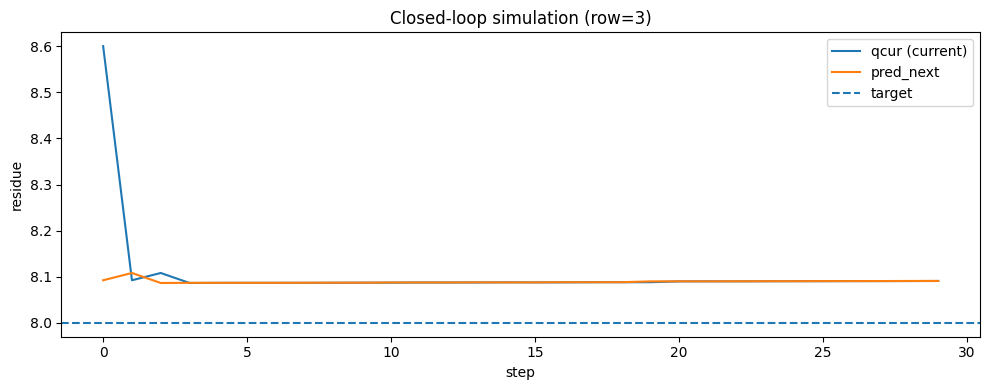

In [21]:
# ============================================================
# 8) 품질 수렴 그래프
# ============================================================

plt.figure(figsize=(10,4))
plt.plot(sim_df["step"], sim_df["qcur"], label="qcur (current)")
plt.plot(sim_df["step"], sim_df["pred_next"], label="pred_next")
plt.axhline(sim_df["target"].iloc[0], linestyle="--", label="target")
plt.xlabel("step")
plt.ylabel("residue")
plt.title(f"Closed-loop simulation (row={ROW_IDX})")
plt.legend()
plt.tight_layout()
plt.show()


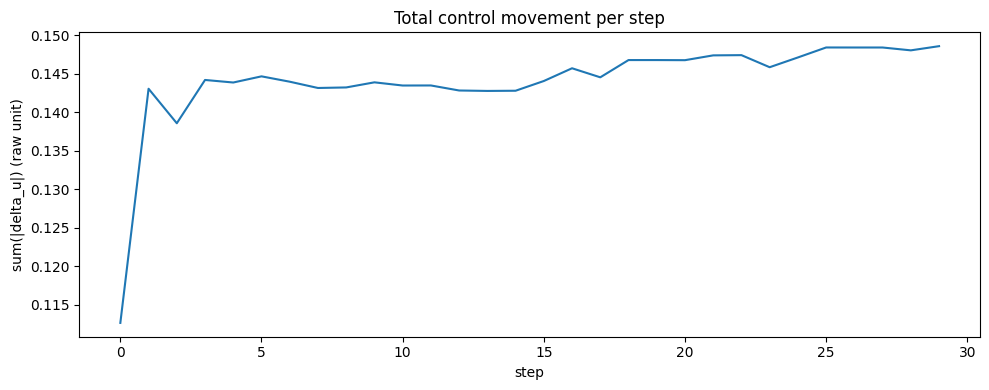

,step,qcur,pred_next,err(target-pred_next),RP_roller_p1_delta,RP_roller_p2_delta,RP_sep_rpm_delta,RP_sep_fan_damper_delta,RP_sep_BF_damper_delta,mill_BF_damper_delta,mill_sep_rpm_delta,mill_sep_fan_damper_delta,grind_aid_delta
0,0,8.900000,8.514277,-0.514277,-0.007416,-0.014458,-0.000458,0.0,-0.000854,0.000475,-0.082642,0.0,0.006317
1,1,8.514277,8.544865,-0.544865,-0.007317,-0.014145,0.000336,0.0,-0.000790,0.000553,-0.104736,0.0,0.015182
2,2,8.544865,8.478407,-0.478407,-0.007195,-0.013840,0.000366,0.0,-0.000744,0.000431,-0.103516,0.0,0.012482
3,3,8.478407,8.484695,-0.484695,-0.007011,-0.014244,0.000397,0.0,-0.000782,0.000521,-0.106689,0.0,0.014557
4,4,8.484695,8.471147,-0.471147,-0.007126,-0.014343,0.000305,0.0,-0.000790,0.000532,-0.105835,0.0,0.014938
5,5,8.471147,8.472361,-0.472361,-0.007248,-0.014290,0.000183,0.0,-0.000748,0.000513,-0.107056,0.0,0.014633
6,6,8.472361,8.470662,-0.470662,-0.007240,-0.014328,0.000153,0.0,-0.000759,0.000523,-0.106567,0.0,0.014404
7,7,8.470662,8.470662,-0.470662,-0.007362,-0.014343,0.000153,0.0,-0.000740,0.000504,-0.106445,0.0,0.013611
8,8,8.470662,8.470595,-0.470595,-0.007370,-0.014343,0.000214,0.0,-0.000740,0.000505,-0.106445,0.0,0.013611
9,9,8.470595,8.470097,-0.470097,-0.007233,-0.014183,0.000153,0.0,-0.000782,0.000479,-0.107910,0.0,0.013153


In [17]:
# ============================================================
# 9) 각 제어변수 변화량 누적 확인
# ============================================================

delta_cols = [f"{c}_delta" for c in CONTROL_COLS_9]

plt.figure(figsize=(10,4))
plt.plot(sim_df["step"], np.abs(sim_df[delta_cols]).sum(axis=1))
plt.xlabel("step")
plt.ylabel("sum(|delta_u|) (raw unit)")
plt.title("Total control movement per step")
plt.tight_layout()
plt.show()

display(sim_df[["step", "qcur", "pred_next", "err(target-pred_next)"] + delta_cols].head(10))
